# Neuromap Playground

### To Do:
- sparse_from_igraph analogously to sparse_from_networkx
- Neuromap helper funcs file for our project in src?


In [2]:
%matplotlib inline

import sys
sys.path.append("..") # go to parent folder

from abc                  import abstractmethod
from numpy                import inf
from torch                import Tensor
from torch.nn             import Parameter
from torch.nn.functional  import softmax, sigmoid
from torch_geometric.nn   import GCN
from torch_geometric.data import Data
from typing               import Dict, List, Tuple

import networkx as nx
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn           as sb
import scipy
import pandas            as pd


import torch_geometric.utils as utils
import torch_geometric.transforms as T
import igraph as ig
import networkx as nx
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx

import neuromap as nm

d:\lightglue_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Prefer CUDA if available, else MPS (Apple Silicon), else CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
print("Device:", device)

Device: cuda


some helper funcs:

In [3]:
def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()


def visualize_embedding(h, color, epoch=None, loss=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    h = h.detach().cpu().numpy()
    plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
    if epoch is not None and loss is not None:
        plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    plt.show()

Mayyyybe let's start with a super simple, basic application of FastGCN, just using the KarateClub dataset:

In [4]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


In [5]:
data = dataset[0]
print(data) #edge_index holds src dst node indices
# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True


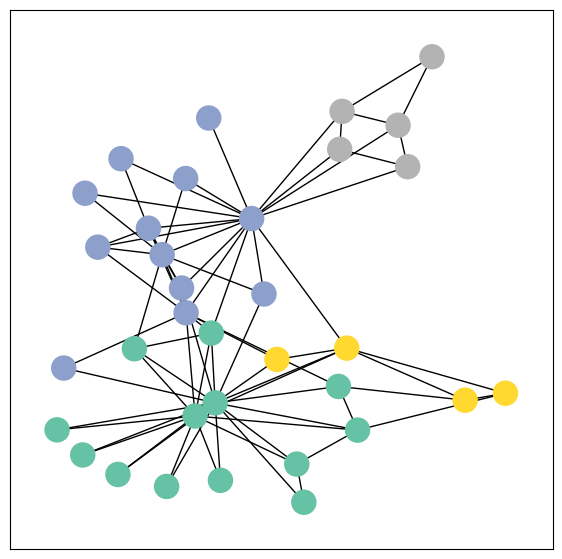

In [6]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

### GCN: Supervised community detection (Karate club)
First, let's use a super normal GCN:

It has 3 graph convolution layers, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 "hops" away). In addition, the GCNConv layers reduce the node feature dimensionality to 2, i.e., 34→4→4→2. Each GCNConv layer is enhanced by a tanh non-linearity.

In [7]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.
        
        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h # return both classification out and node embeddings h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


Embedding shape: [34, 2]


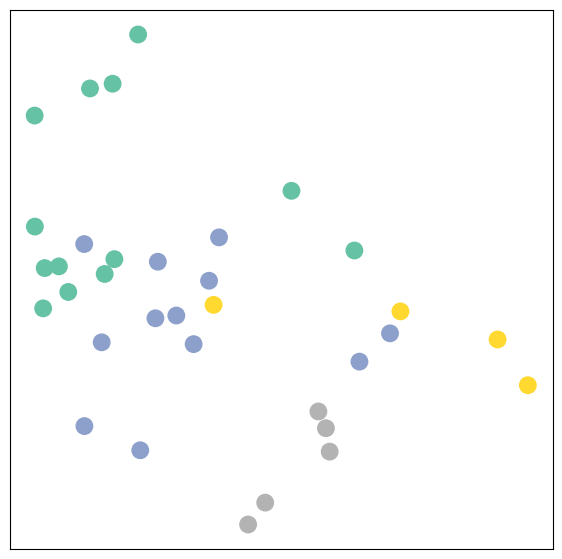

In [8]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize_embedding(h, color=data.y)

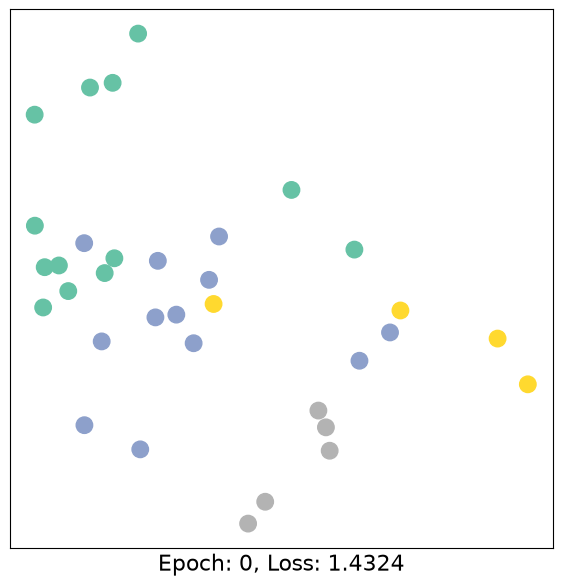

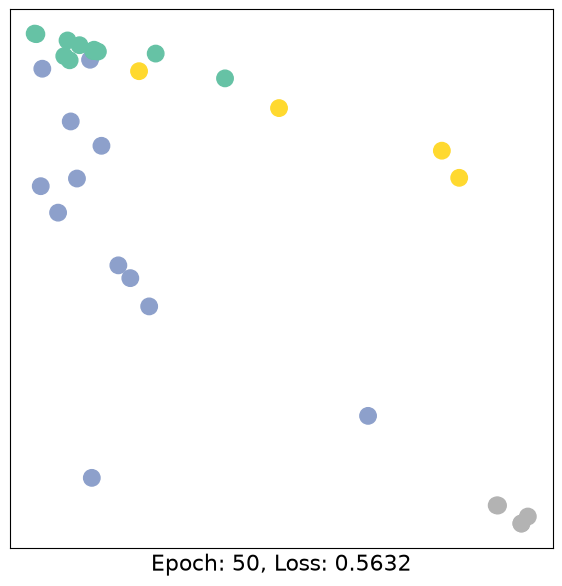

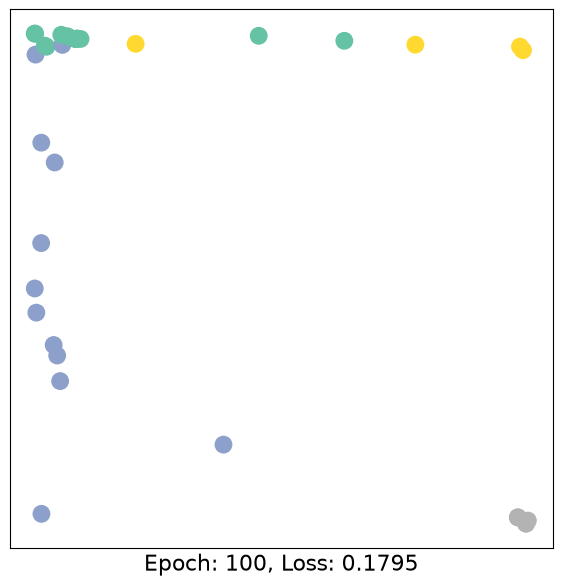

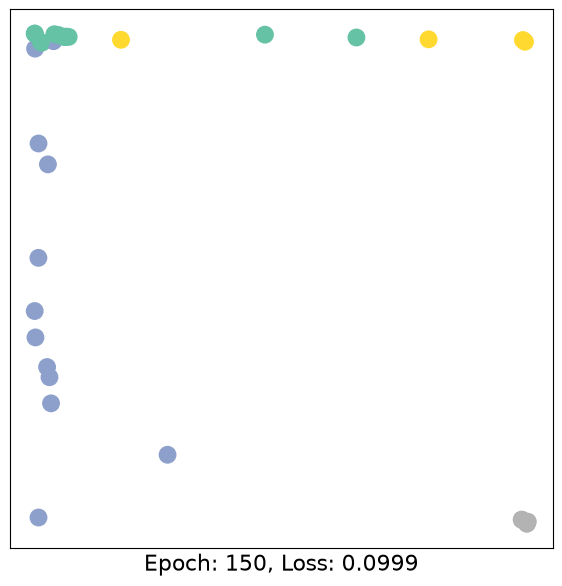

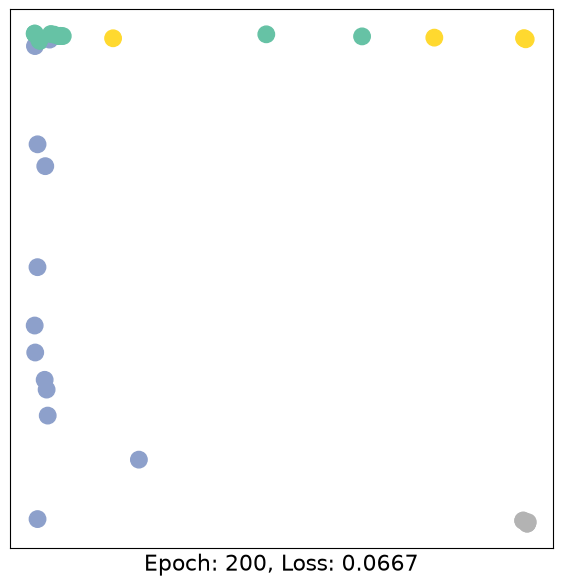

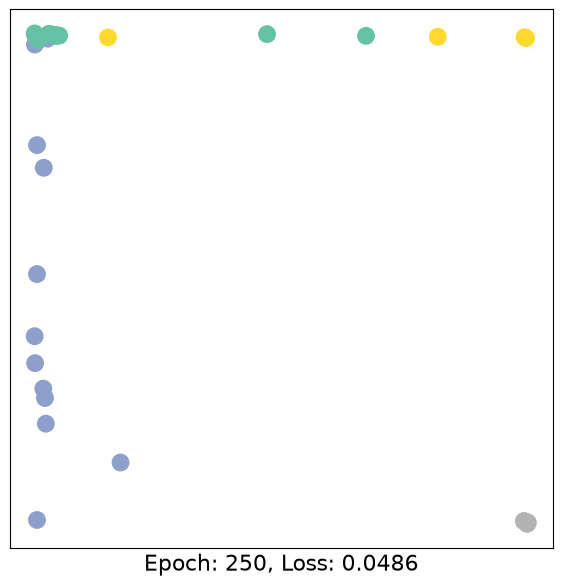

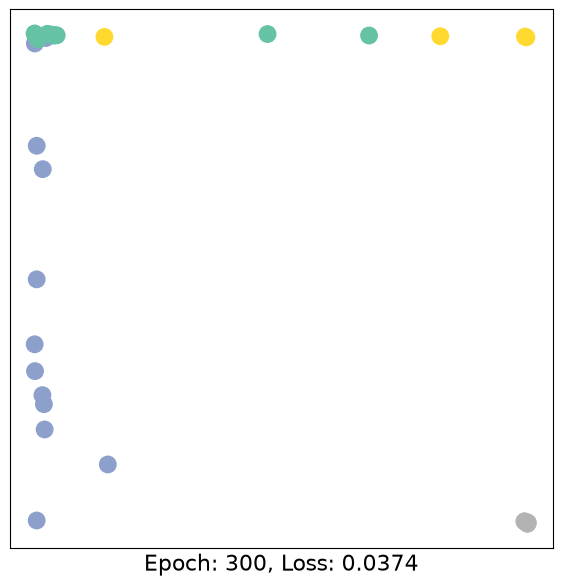

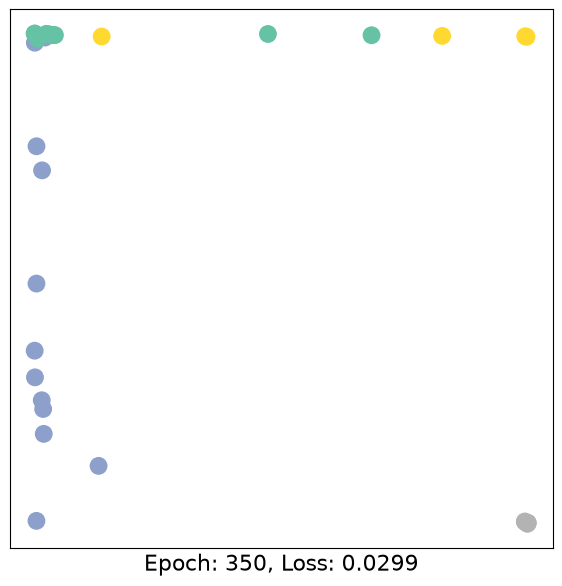

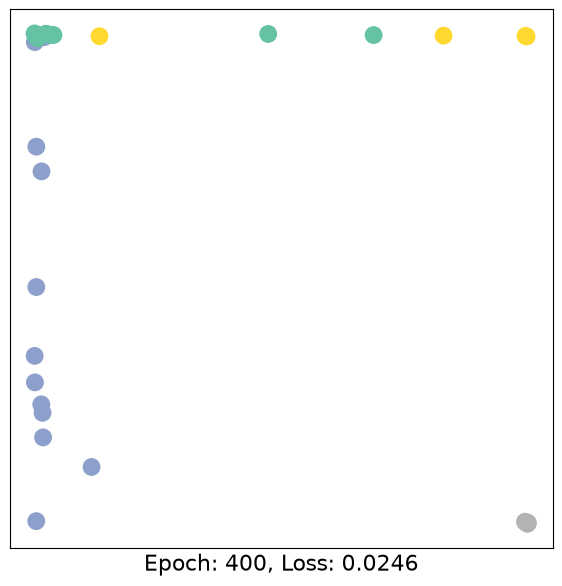

In [9]:
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h

for epoch in range(401): # train 400 epochs
    loss, h = train(data)
    if epoch % 50 == 0:
        visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3) #why???????

In [10]:
def test():
      model.eval()
      out, _ = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      test_correct = pred[~data.train_mask] == data.y[~data.train_mask]  # Check against ground-truth labels.
      test_acc = int(test_correct.sum()) / int((~data.train_mask).sum())  # Derive ratio of correct predictions.
      return test_acc

test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8000


## GCN with Neuromap on Karate Club
Now for community detection with Neuromap!!

These are slightly simplified, and the neuromap repo contains the more specific version where the different models have already been prepped such that they can simply be called with a string, which I don't think we will use anyways.

In [11]:
from torch_geometric.nn   import GCN

In [12]:
data = nm.to_dataset(G = G, y_true = []) #  this is still the karate club graph from above
n = G.number_of_nodes()

model = GCN( in_channels     = n
           , hidden_channels = n
           , num_layers      = 2
           , out_channels    = n
           , act             = "selu"
           , norm            = "batch"
           , dropout         = 0.5
           )

neuromap = nm.Neuromap(model = model, device = "cpu")
print(neuromap)

Neuromap(
  (model): GCN(34, 34, num_layers=2)
)


In [13]:
# setting a high learning rate for this example
# sometimes, the GNN takes a "wrong turn", so in general, it's a good idea to run several trials
L, S = neuromap.fit(data, epochs = 1000, patience = 100, lr = 1e-1)

[Epoch    0] L = 6.25354719 bits
[Epoch    1] L = 5.34462070 bits
[Epoch    2] L = 4.66893196 bits
[Epoch    3] L = 4.43350887 bits
[Epoch    4] L = 4.45611382 bits
[Epoch    5] L = 4.49698496 bits
[Epoch    6] L = 4.44478321 bits
[Epoch    7] L = 4.32263041 bits
[Epoch    8] L = 4.35428429 bits
[Epoch    9] L = 4.33567142 bits
[Epoch   10] L = 4.35341072 bits
[Epoch   11] L = 4.34095478 bits
[Epoch   12] L = 4.35620451 bits
[Epoch   13] L = 4.33667278 bits


d:\lightglue_env\Lib\site-packages\torch_geometric\nn\conv\gcn_conv.py:274: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
d:\lightglue_env\Lib\site-packages\torch_geometric\utils\_spmm.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  src = src.to_sparse_csr()


[Epoch   14] L = 4.36751127 bits
[Epoch   15] L = 4.37007284 bits
[Epoch   16] L = 4.36870193 bits
[Epoch   17] L = 4.36898708 bits
[Epoch   18] L = 4.36511087 bits
[Epoch   19] L = 4.33462763 bits
[Epoch   20] L = 4.32789660 bits
[Epoch   21] L = 4.33221483 bits
[Epoch   22] L = 4.33466339 bits
[Epoch   23] L = 4.32887840 bits
[Epoch   24] L = 4.41990471 bits
[Epoch   25] L = 4.32474899 bits
[Epoch   26] L = 4.40248775 bits
[Epoch   27] L = 4.32316589 bits
[Epoch   28] L = 4.40757179 bits
[Epoch   29] L = 4.32315731 bits
[Epoch   30] L = 4.35346460 bits
[Epoch   31] L = 4.40107298 bits
[Epoch   32] L = 4.34491825 bits
[Epoch   33] L = 4.32330227 bits
[Epoch   34] L = 4.34308481 bits
[Epoch   35] L = 4.37089634 bits
[Epoch   36] L = 4.37186241 bits
[Epoch   37] L = 4.32337856 bits
[Epoch   38] L = 4.32315636 bits
[Epoch   39] L = 4.48668289 bits
[Epoch   40] L = 4.38476753 bits
[Epoch   41] L = 4.37104416 bits
[Epoch   42] L = 4.48681307 bits
[Epoch   43] L = 4.39495897 bits
[Epoch   4

ValueError: too many values to unpack (expected 2)

In [ ]:
# ground truth
Y = torch.zeros(n, dataset[0].y.max().item() + 1)
for i in range(n):
    Y[i, dataset[0].y[i]] = 1
nm.plot_overlapping(G, S =Y, figsize = (3,3))

In [ ]:
# neuromap output
nm.plot_overlapping(G, S =S, figsize = (3,3))

Other models!!!

In [ ]:
from torch_geometric.nn   import GIN, GAT, GraphSAGE

In [ ]:
data = nm.to_dataset(G = G, y_true = []) #  this is still the karate club graph from above
n = G.number_of_nodes()

model = GIN( in_channels     = n
           , hidden_channels = n
           , num_layers      = 3
           , out_channels    = n
           , act             = "selu"
           , norm            = "batch"
           , dropout         = 0.5
           )

neuromap = nm.Neuromap(model = model, device = "cpu")
print(neuromap)

In [ ]:
# setting a high learning rate for this example
# sometimes, the GNN takes a "wrong turn", so in general, it's a good idea to run several trials
L, S = neuromap.fit(data, epochs = 10000, patience = 100, lr = 5e-2)

In [ ]:
nm.plot_overlapping(G, S =S, figsize = (3,3))

In [ ]:
from utils import generate_sbm

g_test = generate_sbm(n=50, c=5, p_in=0.25, p_out=0.01, directed=False, weighted=True)
G = g_test.to_networkx()
data = nm.to_dataset(G, g_test.vs["community"])
#g_test_directed = generate_sbm(n=100, c=6, p_in=0.25, p_out=0.01, directed=True, weighted=True)

In [ ]:
n = G.number_of_nodes()

model = GIN( in_channels     = n
           , hidden_channels = n
           , num_layers      = 2
           , out_channels    = n
           , act             = "selu"
           , norm            = "batch"
           , dropout         = 0.5
           )

neuromap = nm.Neuromap(model = model, device = "cpu")
print(neuromap)

In [ ]:
# setting a high learning rate for this example
# sometimes, the GNN takes a "wrong turn", so in general, it's a good idea to run several trials
L, S = neuromap.fit(data, epochs = 1000, patience = 100, lr = 1e-1)

In [ ]:
nm.plot_overlapping(G, S = S, figsize = (5,5))

whoooops, some plotting issues

## HYPERPARAMETER TUNING

In [14]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA RTX A5000


In [15]:
from torch_geometric.datasets import WikiCS
from torch_geometric.utils import to_networkx

dataset = WikiCS(root="data/WikiCS")
data = dataset[0]
G = to_networkx(
    data,
    to_undirected=True
)
data = nm.to_dataset(
    G=G,
    y_true=[]
)


D:\temp\ipykernel_11408\4033331565.py:4: UserWarning: The WikiCS dataset now returns an undirected graph by default. Please explicitly specify 'is_undirected=False' to restore the old behavior.
  dataset = WikiCS(root="data/WikiCS")


In [16]:
data = data.to(device)

In [ ]:
print(data.x.device)
print(data.edge_index.device)
print(next(model.parameters()).device)

cuda:0
cuda:0
cpu


In [ ]:
from itertools import product
import pandas as pd
import numpy as np
import torch
import time
import os

MODEL_CLASS = GCN
MODEL_NAME = "GCN"

csv_file = f"{MODEL_NAME}_hyperparameter_results.csv"

n = G.number_of_nodes()

param_grid = {
    "num_layers": [1, 2, 3, 4],
    "hidden_channels": [n // 2, n, n * 2],
    "dropout": [0.01, 0.2, 0.5],
    "lr": [0.0001, 0.001, 0.01, 0.05],
}

configs = list(product(
    param_grid["num_layers"],
    param_grid["hidden_channels"],
    param_grid["dropout"],
    param_grid["lr"],
))

# --------------------------------------------------
# Load existing results (for resume capability)
# --------------------------------------------------

if os.path.exists(csv_file):
    existing_df = pd.read_csv(csv_file)

    completed_configs = set(
        zip(
            existing_df["num_layers"],
            existing_df["hidden_channels"],
            existing_df["dropout"],
            existing_df["lr"]
        )
    )

    print(f"Found {len(completed_configs)} completed configurations.")
else:
    existing_df = pd.DataFrame()
    completed_configs = set()

print(f"\nRunning up to {len(configs)} configurations...\n")

# --------------------------------------------------
# Main loop
# --------------------------------------------------

for run_id, (num_layers,
             hidden_channels,
             dropout,
             lr) in enumerate(configs):

    config_key = (
        num_layers,
        hidden_channels,
        dropout,
        lr
    )

    if config_key in completed_configs:
        print(
            f"SKIPPING "
            f"layers={num_layers}, "
            f"hidden={hidden_channels}, "
            f"dropout={dropout}, "
            f"lr={lr}"
        )
        continue

    print(
        f"[{run_id+1:03d}/{len(configs)}] "
        f"layers={num_layers} "
        f"hidden={hidden_channels} "
        f"dropout={dropout} "
        f"lr={lr}"
    )

    start_time = time.perf_counter()

    try:

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        model = MODEL_CLASS(
            in_channels=n,
            hidden_channels=hidden_channels,
            num_layers=num_layers,
            out_channels=n,
            act="selu",
            norm="batch",
            dropout=dropout,
        ).to(device)

        neuromap = nm.Neuromap(
            model=model,
            device=device
        )

        L, S, epochs = neuromap.fit(
            data,
            epochs=100,
            patience=5,
            lr=lr,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        runtime_sec = (time.perf_counter() - start_time) * (100 / epochs)

        if isinstance(L, (list, tuple)):
            best_L = min(L)
            best_epoch = int(np.argmin(L))
        else:
            best_L = float(L)
            best_epoch = -1

    except Exception as e:

        runtime_sec = time.perf_counter() - start_time

        print(f"FAILED: {e}")

        best_L = np.nan
        best_epoch = np.nan

    # --------------------------------------------------
    # Save THIS RESULT immediately
    # --------------------------------------------------

    row = pd.DataFrame([{
        "model": MODEL_NAME,
        "num_layers": num_layers,
        "hidden_channels": hidden_channels,
        "dropout": dropout,
        "lr": lr,
        "best_L": best_L,
        "best_epoch": best_epoch,
        "runtime_sec": runtime_sec,
    }])

    write_header = not os.path.exists(csv_file)

    row.to_csv(
        csv_file,
        mode="a",
        header=write_header,
        index=False
    )

    print(
        f"Saved result:"
        f" L={best_L},"
        f" time={runtime_sec:.2f}s"
    )
    
    if "model" in locals():
        del model

    if "neuromap" in locals():
        del neuromap

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# --------------------------------------------------
# Final summary
# --------------------------------------------------

results_df = pd.read_csv(csv_file)

results_df = results_df.sort_values(
    "best_L",
    ascending=True
)

print("\n")
print("=" * 80)
print(f"TOP 20 CONFIGURATIONS ({MODEL_NAME})")
print("=" * 80)

display(results_df.head(20))

Found 2 completed configurations.

Running up to 144 configurations...

SKIPPING layers=1, hidden=5850, dropout=0.01, lr=0.0001
SKIPPING layers=1, hidden=5850, dropout=0.01, lr=0.001
[003/144] layers=1 hidden=5850 dropout=0.01 lr=0.01
[Epoch    0] L = 14.29665375 bits
[Epoch    1] L = 14.29656601 bits
[Epoch    2] L = 14.29569244 bits
[Epoch    3] L = 14.29147530 bits
[Epoch    4] L = 14.27834320 bits
[Epoch    5] L = 14.24766922 bits
[Epoch    6] L = 14.18986511 bits
[Epoch    7] L = 14.09364128 bits
[Epoch    8] L = 13.94938850 bits
[Epoch    9] L = 13.76309013 bits
[Epoch   10] L = 13.50056076 bits
[Epoch   11] L = 13.17553616 bits
[Epoch   12] L = 12.75710487 bits
[Epoch   13] L = 12.36361122 bits
[Epoch   14] L = 12.16324234 bits
[Epoch   15] L = 12.02483559 bits
[Epoch   16] L = 11.82592773 bits
[Epoch   17] L = 11.72058105 bits
[Epoch   18] L = 11.63377380 bits
[Epoch   19] L = 11.56500530 bits
[Epoch   20] L = 11.52050972 bits
[Epoch   21] L = 11.49833488 bits
[Epoch   22] L = 

d:\lightglue_env\Lib\site-packages\torch_geometric\nn\conv\gcn_conv.py:274: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)


[Epoch    0] L = 14.29665947 bits
[Epoch    1] L = 14.28779030 bits
[Epoch    2] L = 14.07016945 bits
[Epoch    3] L = 13.32583046 bits
[Epoch    4] L = 12.23883343 bits
[Epoch    5] L = 11.61299896 bits
[Epoch    6] L = 11.39280510 bits
[Epoch    7] L = 11.25562668 bits
[Epoch    8] L = 11.20443344 bits
[Epoch    9] L = 11.17161274 bits
[Epoch   10] L = 11.14963531 bits
[Epoch   11] L = 11.12845230 bits
[Epoch   12] L = 11.11180401 bits
[Epoch   13] L = 11.10083008 bits
[Epoch   14] L = 11.08922195 bits
[Epoch   15] L = 11.08069038 bits
[Epoch   16] L = 11.07485867 bits
[Epoch   17] L = 11.06842136 bits
[Epoch   18] L = 11.06327248 bits
[Epoch   19] L = 11.06012821 bits
[Epoch   20] L = 11.05741310 bits
[Epoch   21] L = 11.05580711 bits
[Epoch   22] L = 11.05461788 bits
[Epoch   23] L = 11.05334663 bits
[Epoch   24] L = 11.05212879 bits
[Epoch   25] L = 11.05105591 bits
[Epoch   26] L = 11.05010319 bits
[Epoch   27] L = 11.04922199 bits
[Epoch   28] L = 11.04837322 bits
[Epoch   29] L

d:\lightglue_env\Lib\site-packages\torch_geometric\nn\conv\gcn_conv.py:274: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)


[Epoch    0] L = 14.29665756 bits
[Epoch    1] L = 14.29665947 bits
[Epoch    2] L = 14.29665375 bits
[Epoch    3] L = 14.29665756 bits
[Epoch    4] L = 14.29665756 bits
[Epoch    5] L = 14.29665565 bits
[Epoch    6] L = 14.29665375 bits
[Epoch    7] L = 14.29665756 bits
Saved result: L=14.296184539794922, time=281.89s
[006/144] layers=1 hidden=5850 dropout=0.2 lr=0.001


...

[Epoch    0] L = 14.17914772 bits
[Epoch    1] L = 11.64244270 bits
[Epoch    2] L = 11.69896126 bits
[Epoch    3] L = 11.68794537 bits
[Epoch    4] L = 11.59820366 bits
[Epoch    5] L = 11.46787262 bits
Saved result: L=11.359248161315918, time=597.94s
[132/144] layers=4 hidden=11701 dropout=0.5 lr=0.05


d:\lightglue_env\Lib\site-packages\torch_geometric\nn\conv\gcn_conv.py:274: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)


[Epoch    0] L = 14.18742943 bits
[Epoch    1] L = 11.84765530 bits
[Epoch    2] L = 11.46197701 bits
[Epoch    3] L = 11.08452415 bits
[Epoch    4] L = 11.03554058 bits
[Epoch    5] L = 11.12400436 bits
[Epoch    6] L = 11.05378628 bits
[Epoch    7] L = 11.03348351 bits
[Epoch    8] L = 11.03446579 bits
[Epoch    9] L = 11.02464676 bits
[Epoch   10] L = 11.01582432 bits
[Epoch   11] L = 11.00618649 bits
[Epoch   12] L = 11.00068855 bits
[Epoch   13] L = 11.00582790 bits
[Epoch   14] L = 10.99868393 bits
[Epoch   15] L = 11.00319099 bits
[Epoch   16] L = 11.00155544 bits
[Epoch   17] L = 11.00177765 bits
[Epoch   18] L = 11.00868797 bits
[Epoch   19] L = 11.01308250 bits
[Epoch   20] L = 11.03027248 bits
[Epoch   21] L = 11.01073551 bits
[Epoch   22] L = 10.98655415 bits
[Epoch   23] L = 10.97509575 bits
[Epoch   24] L = 11.01962662 bits
[Epoch   25] L = 11.01943302 bits
[Epoch   26] L = 10.99205208 bits
Saved result: L=11.012040138244629, time=573.52s
[133/144] layers=4 hidden=23402 d

d:\lightglue_env\Lib\site-packages\torch_geometric\nn\conv\gcn_conv.py:274: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)


[Epoch    0] L = 13.98762131 bits
[Epoch    1] L = 10.76767349 bits
[Epoch    2] L = 10.61379528 bits
[Epoch    3] L = 10.56997108 bits
[Epoch    4] L = 10.55444813 bits
[Epoch    5] L = 10.54844093 bits
[Epoch    6] L = 10.54206085 bits
[Epoch    7] L = 10.53412819 bits
[Epoch    8] L = 10.52941036 bits
[Epoch    9] L = 10.52327347 bits
[Epoch   10] L = 10.51852417 bits
[Epoch   11] L = 10.51471329 bits
[Epoch   12] L = 10.51234627 bits
[Epoch   13] L = 10.50890160 bits
[Epoch   14] L = 10.50721741 bits
[Epoch   15] L = 10.50553703 bits
[Epoch   16] L = 10.50224972 bits
[Epoch   17] L = 10.50060558 bits
[Epoch   18] L = 10.49808598 bits
[Epoch   19] L = 10.49714661 bits
[Epoch   20] L = 10.49643612 bits
[Epoch   21] L = 10.49584198 bits
[Epoch   22] L = 10.49519062 bits
[Epoch   23] L = 10.49452686 bits
[Epoch   24] L = 10.49370384 bits
[Epoch   25] L = 10.49302769 bits
[Epoch   26] L = 10.49219894 bits
[Epoch   27] L = 10.49180031 bits
[Epoch   28] L = 10.49140167 bits
[Epoch   29] L

In [ ]:
from itertools import product
import pandas as pd
import time

MODEL_CLASS = GCN
MODEL_NAME = "GCN"

n = G.number_of_nodes()
param_grid = {
    "num_layers": [1, 2, 3, 4],
    "hidden_channels": [n // 2, n, n * 2],
    "dropout": [0.0, 0.2, 0.5],
    "lr": [0.0001, 0.001, 0.01, 0.05],
}

results = []

configs = list(product(
    param_grid["num_layers"],
    param_grid["hidden_channels"],
    param_grid["dropout"],
    param_grid["lr"],
))

print(f"\nRunning {len(configs)} configurations...\n")

for run_id, (num_layers,
             hidden_channels,
             dropout,
             lr) in enumerate(configs):

    print(
        f"[{run_id+1:03d}/{len(configs)}] "
        f"layers={num_layers} "
        f"hidden={hidden_channels} "
        f"dropout={dropout} "
        f"lr={lr}"
    )

    try:
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start_time = time.perf_counter()

        model = MODEL_CLASS(
            in_channels=n,
            hidden_channels=hidden_channels,
            num_layers=num_layers,
            out_channels=n,
            act="selu",
            norm="batch",
            dropout=dropout,
        ).to(device)

        neuromap = nm.Neuromap(
            model=model,
            device=device
        )

        L, S = neuromap.fit(
            data,
            epochs=100,
            patience=4,
            lr=lr,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        runtime_sec = time.perf_counter() - start_time

        if isinstance(L, (list, tuple)):
            best_L = min(L)
            best_epoch = int(np.argmin(L))
        else:
            best_L = float(L)
            best_epoch = -1

        results.append({
            "model": MODEL_NAME,
            "num_layers": num_layers,
            "hidden_channels": hidden_channels,
            "dropout": dropout,
            "lr": lr,
            "best_L": best_L,
            "best_epoch": best_epoch,
            "runtime_sec": runtime_sec
        })

    except Exception as e:

        print(f"FAILED: {e}")

        results.append({
            "model": MODEL_NAME,
            "num_layers": num_layers,
            "hidden_channels": hidden_channels,
            "dropout": dropout,
            "lr": lr,
            "best_L": np.nan,
            "best_epoch": np.nan,
            "runtime_sec": runtime_sec
        })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="best_L",
    ascending=True
)

print("\n")
print("=" * 80)
print(f"TOP 20 CONFIGURATIONS ({MODEL_NAME})")
print("=" * 80)

display(results_df.head(20))

# Save for later comparison across models
results_df.to_csv(
    f"{MODEL_NAME}_hyperparameter_results.csv",
    index=False
)

print(
    f"\nSaved results to "
    f"{MODEL_NAME}_hyperparameter_results.csv"
)

In [ ]:
display(results_df.tail(20))

In [3]:
gcn = pd.read_csv("GCN_hyperparameter_results.csv")

# Sort by best_L (ascending)
gcn_sorted = gcn.sort_values(by="best_L")

# Top 20 entries (smallest best_L values)
top_20 = gcn_sorted.head(20)
print("Top 20 entries:")
print(top_20)

# Bottom 20 entries (largest best_L values)
bottom_20 = gcn_sorted.tail(20)
print("\nBottom 20 entries:")
print(bottom_20)

Top 20 entries:
    model  num_layers  hidden_channels  dropout      lr     best_L  \
35    GCN           2             5850     0.01  0.0001  10.329430   
47    GCN           2            11701     0.01  0.0001  10.334625   
39    GCN           2             5850     0.20  0.0001  10.336113   
43    GCN           2             5850     0.50  0.0001  10.345547   
59    GCN           2            23402     0.01  0.0001  10.351043   
51    GCN           2            11701     0.20  0.0001  10.351230   
48    GCN           2            11701     0.01  0.0010  10.351782   
91    GCN           3            11701     0.50  0.0001  10.356989   
71    GCN           3             5850     0.01  0.0001  10.359608   
55    GCN           2            11701     0.50  0.0001  10.361604   
42    GCN           2             5850     0.20  0.0500  10.375933   
38    GCN           2             5850     0.01  0.0500  10.380175   
40    GCN           2             5850     0.20  0.0010  10.385173   
52  

In [ ]:
import seaborn as sns

gcn = pd.read_csv("GCN_hyperparameter_results.csv")
gin = pd.read_csv("GIN_hyperparameter_results.csv")
gat = pd.read_csv("GAT_hyperparameter_results.csv")
sage = pd.read_csv("GraphSAGE_hyperparameter_results.csv")

df = pd.concat([gcn, gin, gat, sage])

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="model",
    y="best_L"
)

plt.title("Distribution of Description Lengths by Architecture")
plt.ylabel("Best Description Length (bits)")
plt.xlabel("Model")

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="num_layers",
    y="best_L",
    hue="model",
    marker="o",
    estimator="mean"
)

plt.title("Effect of Number of Layers")
plt.ylabel("Average Description Length")
plt.xlabel("Number of Layers")

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="hidden_channels",
    y="best_L",
    hue="model",
    marker="o",
    estimator="mean"
)

plt.title("Effect of Hidden Dimension")
plt.ylabel("Average Description Length")
plt.xlabel("Hidden Channels")

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="lr",
    y="best_L",
    hue="model",
    marker="o",
    estimator="mean"
)

plt.xscale("log")

plt.title("Learning Rate Sensitivity")
plt.ylabel("Average Description Length")
plt.xlabel("Learning Rate")

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x="dropout",
    y="best_L",
    hue="model",
    marker="o",
    estimator="mean"
)

plt.title("Effect of Dropout")
plt.ylabel("Average Description Length")
plt.xlabel("Dropout")

plt.show()